In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/049_4d6df392.jpg
/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/051_268fdfd7.jpg
/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/045_c560251e.jpg
/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/052_6db5f5bf.jpg
/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/006_9135205d.jpg
/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/020_4c4b655f.jpg
/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/025_41cee764.jpg
/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset/Angelina Jolie/024_ca32be97.jpg
/kaggle/input/datasets/vishesh1412/celeb

✓ Found dataset at: /kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset
Using device: cuda
Found 1800 images across 17 classes:
  • Angelina Jolie
  • Brad Pitt
  • Denzel Washington
  • Hugh Jackman
  • Jennifer Lawrence
  • Johnny Depp
  • Kate Winslet
  • Leonardo DiCaprio
  • Megan Fox
  • Natalie Portman
  • Nicole Kidman
  • Robert Downey Jr
  • Sandra Bullock
  • Scarlett Johansson
  • Tom Cruise
  • Tom Hanks
  • Will Smith

Split: 1259 train / 270 val / 271 test


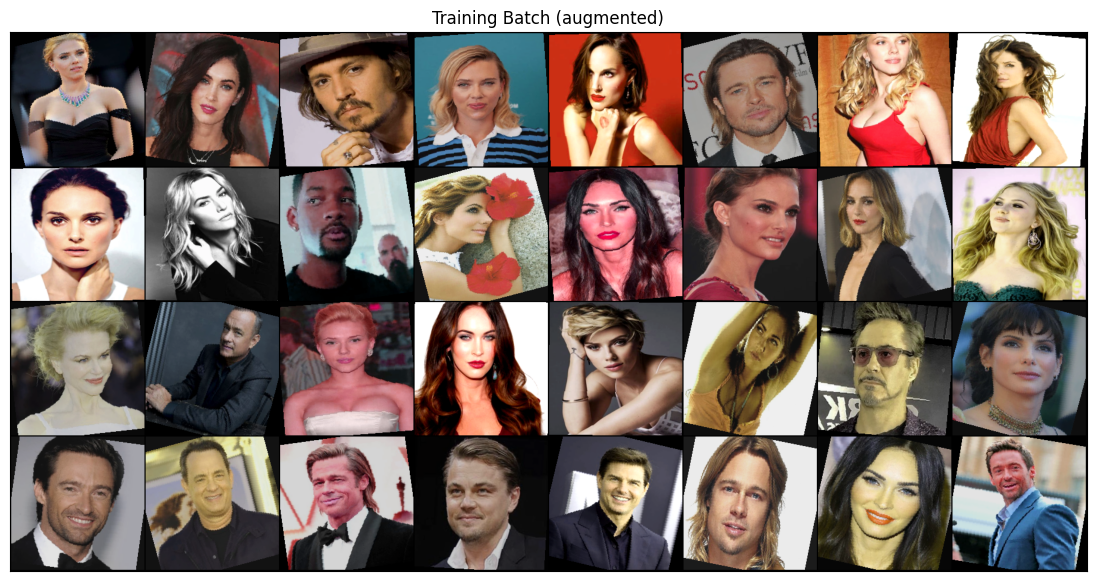

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 155MB/s]


Model: ResNet18
Total parameters:     11,185,233
Trainable parameters: 8,721

PHASE 1: Training classifier head (backbone frozen)


Epoch [ 1/15]  train_loss: 2.8641  train_acc: 0.1094  val_loss: 2.4254  val_acc: 0.2312  lr: 0.000989
Epoch [ 2/15]  train_loss: 2.3893  train_acc: 0.2156  val_loss: 2.1857  val_acc: 0.2808  lr: 0.000957
Epoch [ 3/15]  train_loss: 2.1691  train_acc: 0.3011  val_loss: 2.0759  val_acc: 0.3051  lr: 0.000905
Epoch [ 4/15]  train_loss: 2.0481  train_acc: 0.3318  val_loss: 1.9502  val_acc: 0.3304  lr: 0.000835
Epoch [ 5/15]  train_loss: 1.9048  train_acc: 0.3834  val_loss: 1.9069  val_acc: 0.3651  lr: 0.000750
Epoch [ 6/15]  train_loss: 1.8067  train_acc: 0.4145  val_loss: 1.8305  val_acc: 0.3591  lr: 0.000655
Epoch [ 7/15]  train_loss: 1.8081  train_acc: 0.4223  val_loss: 1.7640  val_acc: 0.3800  lr: 0.000552
Epoch [ 8/15]  train_loss: 1.7165  train_acc: 0.4433  val_loss: 1.7444  val_acc: 0.3780  lr: 0.000448
Epoch [ 9/15]  train_loss: 1.7363  train_acc: 0.4333  val_loss: 1.7183  val_acc: 0.3904  lr: 0.000345
Epoch [10/15]  train_loss: 1.7274  train_acc: 0.4357  val_loss: 1.7076  val_acc: 0

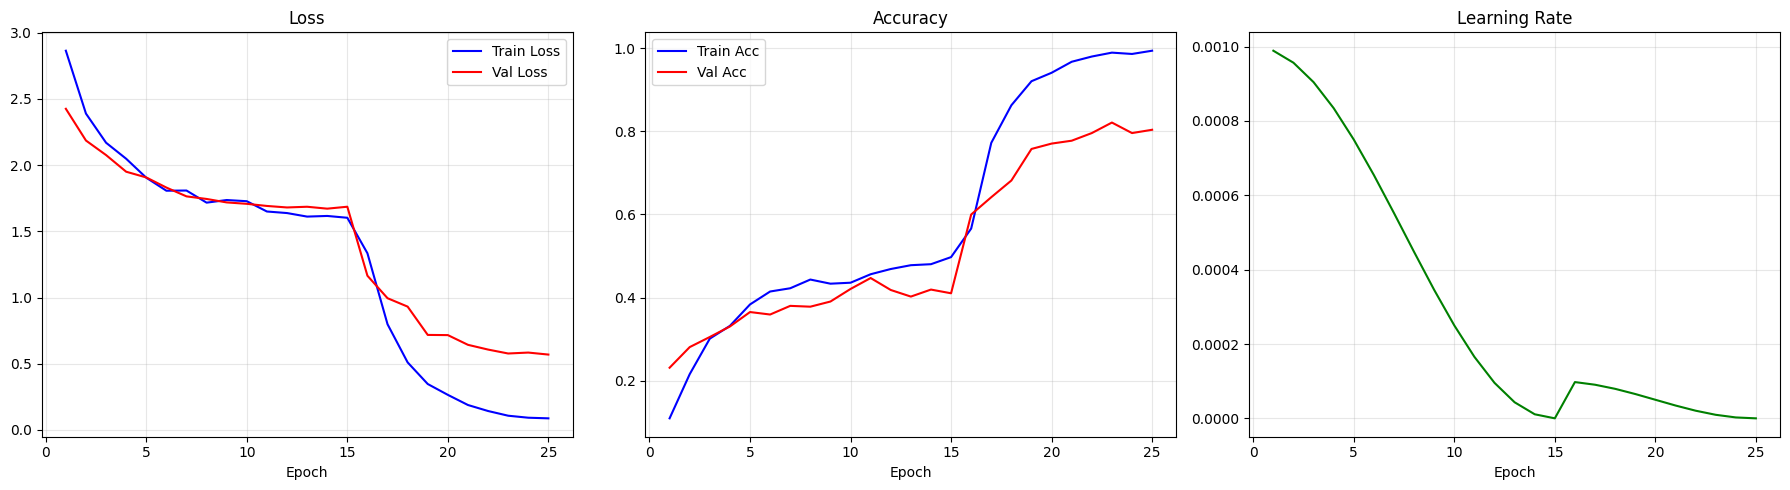


FINAL EVALUATION ON TEST SET
Test Loss:     0.4679
Test Accuracy: 0.8523

Per-class Results:
                    precision    recall  f1-score   support

    Angelina Jolie       0.72      0.87      0.79        15
         Brad Pitt       0.93      0.87      0.90        15
 Denzel Washington       0.76      0.87      0.81        15
      Hugh Jackman       0.92      0.80      0.86        15
 Jennifer Lawrence       0.92      0.73      0.81        15
       Johnny Depp       1.00      0.93      0.97        15
      Kate Winslet       0.80      0.80      0.80        15
 Leonardo DiCaprio       0.93      0.93      0.93        15
         Megan Fox       0.88      1.00      0.94        15
   Natalie Portman       0.83      0.67      0.74        15
     Nicole Kidman       0.93      0.93      0.93        15
  Robert Downey Jr       0.87      0.87      0.87        15
    Sandra Bullock       1.00      0.67      0.80        15
Scarlett Johansson       0.77      0.97      0.86        31
     

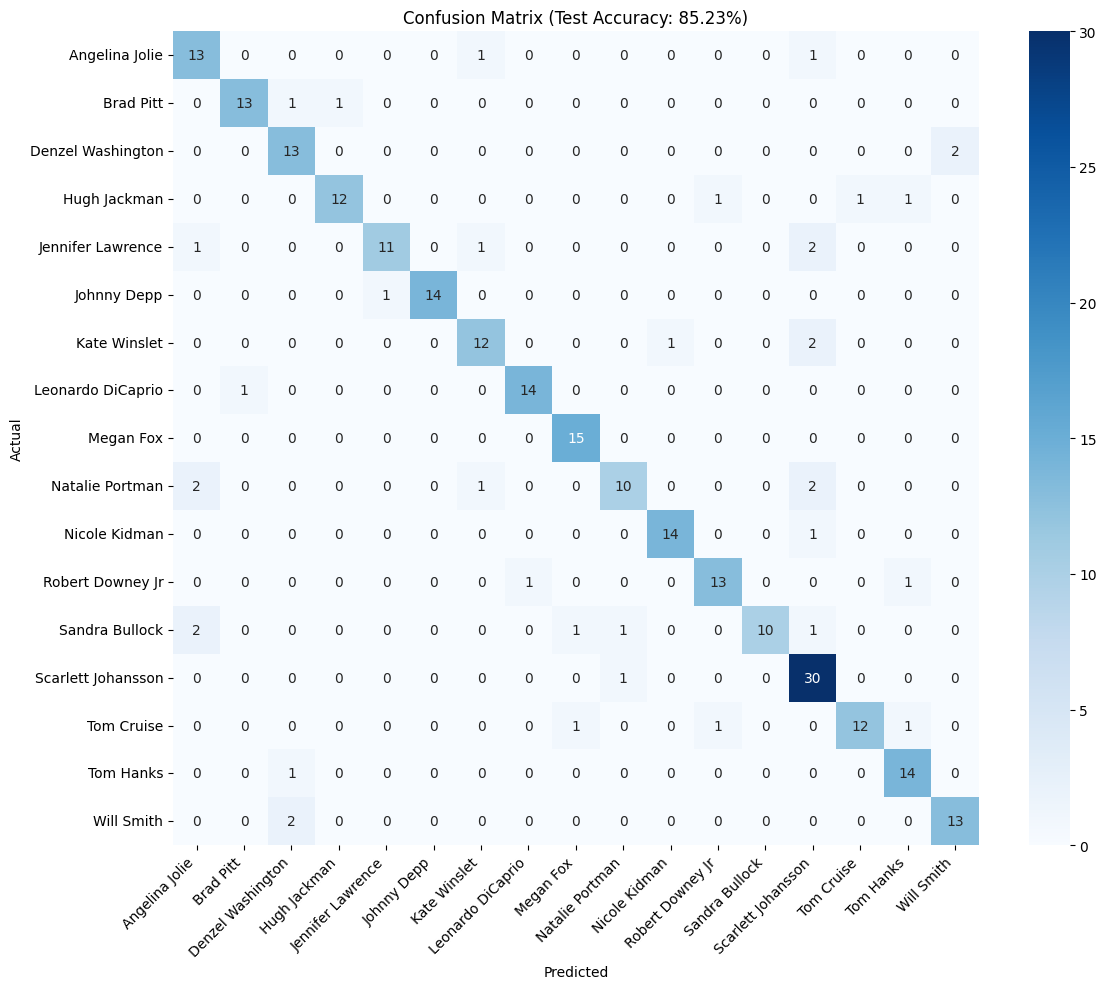


✓ Model saved to /kaggle/working/celebrity_recognizer_v2.pth

✓ All done! Use predict_celebrity() for inference.


In [2]:
"""
Celebrity Face Recognizer v2 — Improved Edition
================================================
A PyTorch image classifier that recognizes 17 celebrities from face images.
Uses ResNet18 transfer learning with proper data augmentation for high accuracy.

Dataset: "Celebrity Face Image Dataset" on Kaggle
  → /kaggle/input/celebrity-face-image-dataset/Celebrity Faces Dataset

Usage:
  1. Upload this script to a Kaggle notebook (or paste into cells).
  2. Attach the "Celebrity Face Image Dataset".
  3. Enable GPU accelerator.
  4. Run all cells.

Author: RoaimKhan
"""

# 1. IMPORTS

import os
import copy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 2. CONFIGURATION

# Paths — auto-detect the dataset folder on Kaggle
SAVE_DIR = Path("/kaggle/working")

def find_dataset_dir():
    """Auto-detect the celebrity dataset folder under /kaggle/input."""
    base = Path("/kaggle/input")
    if not base.exists():
        raise FileNotFoundError("Not running on Kaggle — set DATA_DIR manually.")
    
    # Search for a directory that contains celebrity-named subfolders
    for dataset_dir in sorted(base.rglob("*")):
        if dataset_dir.is_dir():
            subdirs = [d.name for d in dataset_dir.iterdir() if d.is_dir()]
            # Check if this looks like the celebrity dataset (has multiple subfolders with images)
            if len(subdirs) >= 10:  # Dataset has 17 classes
                # Check if subfolders contain images
                sample_dir = next(dataset_dir.iterdir())
                if sample_dir.is_dir():
                    files = list(sample_dir.iterdir())
                    if any(f.suffix.lower() in ('.jpg', '.jpeg', '.png') for f in files):
                        print(f"✓ Found dataset at: {dataset_dir}")
                        return dataset_dir
    
    # Fallback: try common path patterns
    candidates = [
        base / "celebrity-face-image-dataset" / "Celebrity Faces Dataset",
        base / "celebrity-face-image-dataset" / "celebrity faces dataset",
        base / "celebrity-face-image-dataset",
    ]
    for c in candidates:
        if c.exists():
            print(f"✓ Found dataset at: {c}")
            return c
    
    # Last resort: list what's actually there so the user can set it
    print("Could not auto-detect dataset. Contents of /kaggle/input:")
    for item in sorted(base.rglob("*")):
        if item.is_dir():
            n_children = len(list(item.iterdir()))
            print(f"  {item}  ({n_children} items)")
    raise FileNotFoundError("Set DATA_DIR manually to the folder containing celebrity subfolders.")

DATA_DIR = find_dataset_dir()

# Hyperparameters
IMAGE_SIZE = 224          # Standard size for pretrained models
BATCH_SIZE = 32           # Smaller batch → better generalization, fits GPU memory
NUM_WORKERS = 2           # Parallel data loading
NUM_EPOCHS = 15           # Total training epochs
LEARNING_RATE = 1e-3      # Initial LR for Adam
WEIGHT_DECAY = 1e-4       # L2 regularization
TRAIN_RATIO = 0.70        # 70% train
VAL_RATIO = 0.15          # 15% validation
TEST_RATIO = 0.15         # 15% test
RANDOM_SEED = 42          # Reproducibility

# ImageNet normalization stats (required for pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# 3. DEVICE SETUP — Fixed GPU bug

def get_device():
    """Pick GPU if available, else CPU."""
    if torch.cuda.is_available():
        return torch.device('cuda')      
    else:
        return torch.device('cpu')

device = get_device()
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)


# 4. DATA AUGMENTATION & NORMALIZATION — New in v2

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 5. DATASET LOADING & STRATIFIED SPLIT — New in v2

# Load full dataset (with val/test transform for splitting; we override later)
full_dataset = ImageFolder(DATA_DIR, transform=val_test_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
targets = [s[1] for s in full_dataset.samples]

print(f"Found {len(full_dataset)} images across {num_classes} classes:")
for name in class_names:
    print(f"  • {name}")

# Stratified split: train / val / test
indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(
    indices, test_size=(1 - TRAIN_RATIO),
    stratify=targets, random_state=RANDOM_SEED
)
# Split temp into val and test (50/50 of remaining)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5,
    stratify=temp_targets, random_state=RANDOM_SEED
)

print(f"\nSplit: {len(train_idx)} train / {len(val_idx)} val / {len(test_idx)} test")

# Create subset datasets with appropriate transforms
# Training data gets augmentation transforms
train_dataset = ImageFolder(DATA_DIR, transform=train_transform)
train_subset = Subset(train_dataset, train_idx)

# Val/test data gets simple transforms (no augmentation)
val_subset = Subset(full_dataset, val_idx)
test_subset = Subset(full_dataset, test_idx)

# DataLoaders with num_workers for speed
train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_subset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)


# 6. VISUALIZE A BATCH

def denormalize(images, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Undo ImageNet normalization for display."""
    mean = torch.tensor(mean).reshape(1, 3, 1, 1)
    std = torch.tensor(std).reshape(1, 3, 1, 1)
    return images * std + mean

def show_batch(loader, title="Batch"):
    """Display a grid of images from a batch."""
    images, labels = next(iter(loader))
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    grid = make_grid(denormalize(images), nrow=8)
    ax.imshow(grid.permute(1, 2, 0).clamp(0, 1))
    plt.show()

show_batch(train_loader, "Training Batch (augmented)")


# 7. MODEL — ResNet18 Transfer Learning (replaces custom CNN)

def create_model(num_classes, freeze_backbone=True):
    """
    Create a ResNet18 model pretrained on ImageNet.
    Replace the final FC layer for our number of classes.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Optionally freeze all backbone layers (only train the classifier head)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final fully-connected layer
    # ResNet18 last layer: model.fc = Linear(512, 1000)
    num_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),          # ← Dropout to reduce overfitting
        nn.Linear(num_features, num_classes)
    )

    return model

model = create_model(num_classes, freeze_backbone=True)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel: ResNet18")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


# 8. TRAINING UTILITIES

def accuracy(outputs, labels):
    """Compute accuracy as a tensor."""
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

def evaluate(model, loader):
    """Evaluate model on a data loader. Returns avg loss and accuracy."""
    model.eval()
    losses = []
    accuracies = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)
            acc = accuracy(outputs, labels)
            losses.append(loss.item())
            accuracies.append(acc.item())
    return {
        'loss': np.mean(losses),
        'accuracy': np.mean(accuracies),
    }


# 9. TRAINING LOOP — Proper implementation with scheduler & checkpointing

def fit(model, train_loader, val_loader, epochs, lr, weight_decay=1e-4):
    """
    Train the model with:
      - Adam optimizer
      - Cosine Annealing LR scheduler
      - Gradient clipping
      - Best-model checkpointing
    """
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = []
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(epochs):
        # --- Training phase ---
        model.train()
        train_losses = []
        train_accuracies = []

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()             # ← Zero gradients first (proper order)
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(         # ← Gradient clipping
                model.parameters(), max_norm=1.0
            )
            optimizer.step()

            train_losses.append(loss.item())
            train_accuracies.append(accuracy(outputs, labels).item())

        # --- Validation phase ---
        val_results = evaluate(model, val_loader)

        # Step the scheduler
        scheduler.step()

        # Record history
        epoch_result = {
            'train_loss': np.mean(train_losses),
            'train_acc': np.mean(train_accuracies),
            'val_loss': val_results['loss'],
            'val_acc': val_results['accuracy'],
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(epoch_result)

        # Checkpointing — save best model
        if val_results['accuracy'] > best_val_acc:
            best_val_acc = val_results['accuracy']
            best_model_state = copy.deepcopy(model.state_dict())

        # Print progress
        print(
            f"Epoch [{epoch+1:>2}/{epochs}]  "
            f"train_loss: {epoch_result['train_loss']:.4f}  "
            f"train_acc: {epoch_result['train_acc']:.4f}  "
            f"val_loss: {epoch_result['val_loss']:.4f}  "
            f"val_acc: {epoch_result['val_acc']:.4f}  "
            f"lr: {epoch_result['lr']:.6f}"
        )

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Restored best model (val_acc: {best_val_acc:.4f})")

    return history


# 10. PHASE 1: Train classifier head (backbone frozen)

print("\n" + "="*60)
print("PHASE 1: Training classifier head (backbone frozen)")
print("="*60)

history_phase1 = fit(
    model, train_loader, val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# 11. PHASE 2: Fine-tune entire model (unfreeze backbone)

print("\n" + "="*60)
print("PHASE 2: Fine-tuning entire model (backbone unfrozen)")
print("="*60)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Fine-tune with a lower learning rate
history_phase2 = fit(
    model, train_loader, val_loader,
    epochs=10,
    lr=LEARNING_RATE / 10,    # ← Lower LR for fine-tuning (0.0001)
    weight_decay=WEIGHT_DECAY
)

# Combine histories
history = history_phase1 + history_phase2


# 12. PLOT TRAINING CURVES

def plot_history(history):
    """Plot training & validation loss and accuracy curves."""
    epochs_range = range(1, len(history) + 1)
    train_losses = [h['train_loss'] for h in history]
    val_losses = [h['val_loss'] for h in history]
    train_accs = [h['train_acc'] for h in history]
    val_accs = [h['val_acc'] for h in history]
    lrs = [h['lr'] for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(epochs_range, train_losses, 'b-', label='Train Loss')
    axes[0].plot(epochs_range, val_losses, 'r-', label='Val Loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_range, train_accs, 'b-', label='Train Acc')
    axes[1].plot(epochs_range, val_accs, 'r-', label='Val Acc')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Learning Rate
    axes[2].plot(epochs_range, lrs, 'g-')
    axes[2].set_title('Learning Rate')
    axes[2].set_xlabel('Epoch')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(SAVE_DIR / 'training_curves.png'), dpi=150)
    plt.show()

plot_history(history)

# 13. EVALUATE ON TEST SET

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

test_results = evaluate(model, test_loader)
print(f"Test Loss:     {test_results['loss']:.4f}")
print(f"Test Accuracy: {test_results['accuracy']:.4f}")

# Per-class predictions for confusion matrix
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("\nPer-class Results:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Test Accuracy: {test_results["accuracy"]:.2%})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'confusion_matrix.png'), dpi=150)
plt.show()


# 14. SAVE MODEL

save_path = SAVE_DIR / 'celebrity_recognizer_v2.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'num_classes': num_classes,
    'image_size': IMAGE_SIZE,
    'architecture': 'resnet18',
}, str(save_path))
print(f"\n✓ Model saved to {save_path}")


# 15. INFERENCE HELPER — Predict on a single image

def predict_celebrity(image_path, model, transform, class_names, device):
    """Predict the celebrity in a single image."""
    from PIL import Image
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)
        top_prob, top_idx = torch.max(probs, dim=1)

    predicted_class = class_names[top_idx.item()]
    confidence = top_prob.item()

    print(f"Predicted: {predicted_class} ({confidence:.1%} confidence)")

    # Show top 5
    top5_probs, top5_indices = torch.topk(probs, 5, dim=1)
    print("\nTop 5 predictions:")
    for prob, idx in zip(top5_probs[0], top5_indices[0]):
        print(f"  {class_names[idx.item()]:>25s}: {prob.item():.1%}")

    return predicted_class, confidence

print("\n✓ All done! Use predict_celebrity() for inference.")
